<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-03-22 12:28:16--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  52.8MB/s    in 3.9s    

2026-03-22 12:28:20 (51.8 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]



#### Install the required libraries and import them


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 127.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 181.6 MB/s eta 0:00:00


In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 110.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 142.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 70.3 MB/s eta 0:00:00


In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [5]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [6]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [7]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


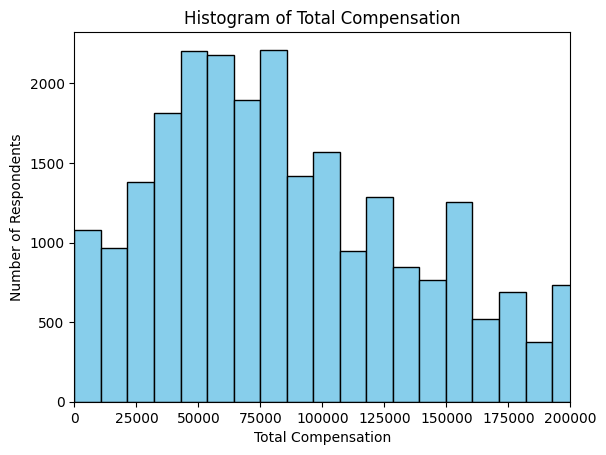

In [9]:
## Write your code here
# 1. Connect to the correct hyphenated file
conn = sqlite3.connect('survey-data.sqlite')

# 2. Query CompTotal from the 'main' table
query = "SELECT CompTotal FROM main"
df = pd.read_sql_query(query, conn)

# 3. Always close the connection
conn.close()

# 1. Calculate the Quartiles and IQR
Q1 = df['CompTotal'].quantile(0.25)
Q3 = df['CompTotal'].quantile(0.75)
IQR = Q3 - Q1

# 2. Define the bounds for 'normal' data
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Create a filtered DataFrame
df_filtered = df[(df['CompTotal'] >= lower_bound) & (df['CompTotal'] <= upper_bound)]

# 4. Plot the histogram
# We use dropna() because survey data often has missing compensation values
plt.hist(df_filtered['CompTotal'].dropna(), bins=50, color='skyblue', edgecolor='black')

# Focus the view on the most common salary range
plt.xlim(0, 200000)

# Lab formatting
plt.title('Histogram of Total Compensation')
plt.xlabel('Total Compensation')
plt.ylabel('Number of Respondents')

plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


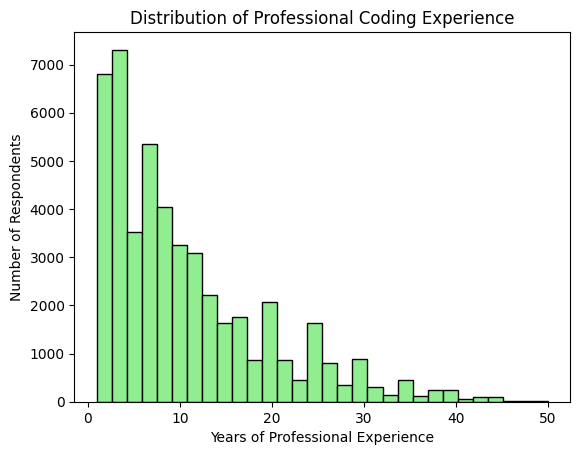

In [10]:
## Write your code here
# 1. Select the data from your 'main' table
conn = sqlite3.connect('survey-data.sqlite')
query = "SELECT YearsCodePro FROM main"
df_experience = pd.read_sql_query(query, conn)

# 2. Convert to numeric (errors='coerce' turns text into NaN so it doesn't break)
df_experience['YearsCodePro'] = pd.to_numeric(df_experience['YearsCodePro'], errors='coerce')

# 3. Plot the histogram
plt.hist(df_experience['YearsCodePro'].dropna(), bins=30, color='lightgreen', edgecolor='black')

# 4. Labeling for the lab
plt.title('Distribution of Professional Coding Experience')
plt.xlabel('Years of Professional Experience')
plt.ylabel('Number of Respondents')

plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


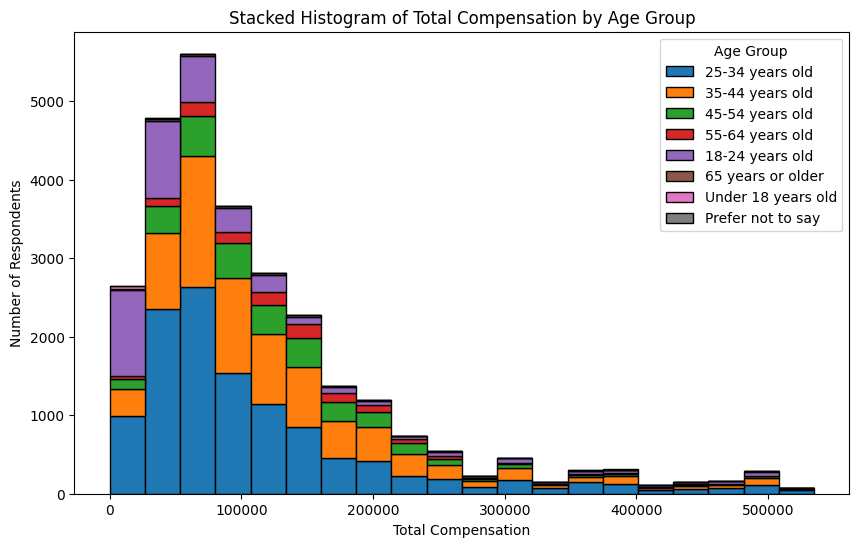

In [11]:
## Write your code here
# 1. Get the data
conn = sqlite3.connect('survey-data.sqlite')
query = "SELECT Age, CompTotal FROM main"
df = pd.read_sql_query(query, conn)
conn.close()

# 2. Filter outliers (as we did before) to keep the x-axis readable
Q1 = df['CompTotal'].quantile(0.25)
Q3 = df['CompTotal'].quantile(0.75)
IQR = Q3 - Q1
df_filtered = df[(df['CompTotal'] >= (Q1 - 1.5 * IQR)) & (df['CompTotal'] <= (Q3 + 1.5 * IQR))]

# 3. Create a list of data for each age group
# This is how Matplotlib handles multiple groups in one histogram
age_groups = df_filtered['Age'].unique()
data_to_plot = [df_filtered[df_filtered['Age'] == age]['CompTotal'] for age in age_groups]

# 4. Plot a single chart
plt.figure(figsize=(10, 6))
plt.hist(data_to_plot, bins=20, stacked=True, label=age_groups, edgecolor='black')

# 5. Add Lab Labels
plt.title('Stacked Histogram of Total Compensation by Age Group')
plt.xlabel('Total Compensation')
plt.ylabel('Number of Respondents')
plt.legend(title='Age Group')

plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


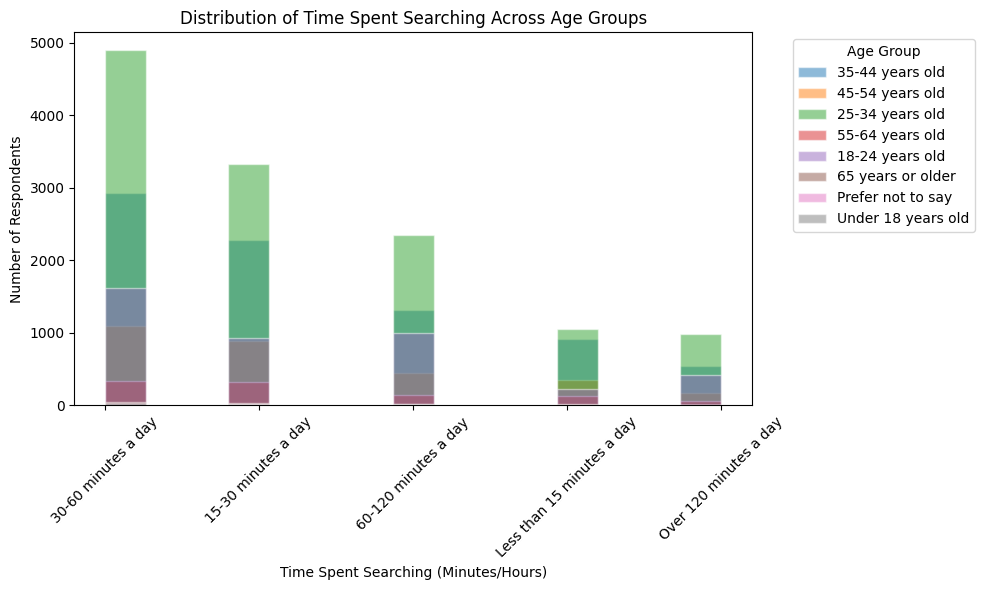

In [12]:
## Write your code here
# 1. Load the data from the correct file
conn = sqlite3.connect('survey-data.sqlite')
query = "SELECT Age, TimeSearching FROM main"
df = pd.read_sql_query(query, conn)
conn.close()

# 2. Clean up missing values
df = df.dropna(subset=['Age', 'TimeSearching'])

# 3. Plotting the Overlaid Histogram
plt.figure(figsize=(10, 6))

# We loop through each age group to plot them on the same axis
for age in df['Age'].unique():
    subset = df[df['Age'] == age]
    plt.hist(subset['TimeSearching'], bins=15, alpha=0.5, label=age, edgecolor='white')

# 4. Professional Lab Formatting
plt.title('Distribution of Time Spent Searching Across Age Groups')
plt.xlabel('Time Spent Searching (Minutes/Hours)')
plt.ylabel('Number of Respondents')

# Rotate labels 45 degrees so they don't lap
plt.xticks(rotation=45)

# The legend is critical here so you know which color is which age
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


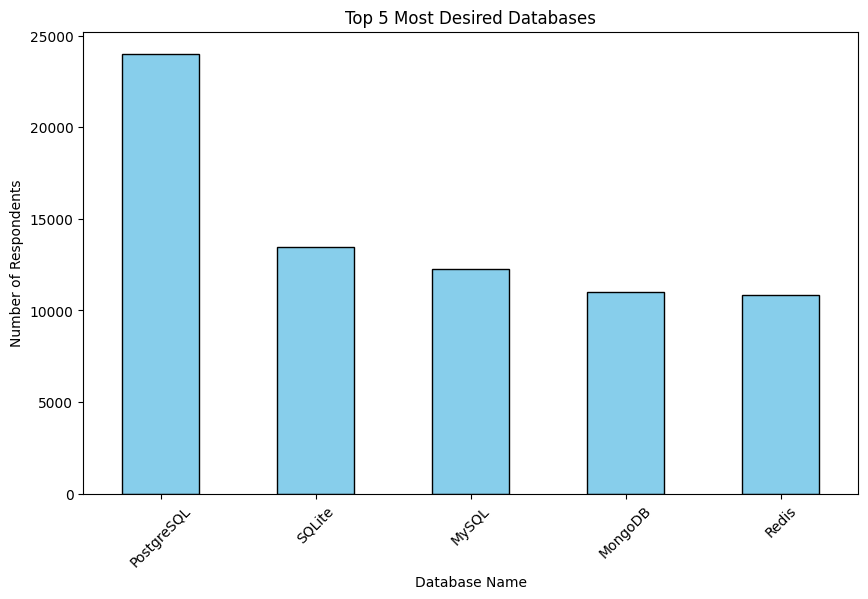

In [13]:
## Write your code here
# 1. Connect to your database
# Ensure you use the exact file name that worked for you before
conn = sqlite3.connect('survey-data.sqlite')

# 2. Query the data from the 'main' table
query = "SELECT DatabaseWantToWorkWith FROM main"
df = pd.read_sql_query(query, conn)
conn.close()

# 3. Clean and process the data
# We drop missing values, split by semicolon, and expand them into individual counts
db_counts = df['DatabaseWantToWorkWith'].str.split(';').explode().value_counts()

# 4. Get the Top 5
top_5_db = db_counts.head(5)

# 5. Create the Visualization
plt.figure(figsize=(10, 6))
top_5_db.plot(kind='bar', color='skyblue', edgecolor='black')

# Professional Formatting
plt.title('Top 5 Most Desired Databases')
plt.xlabel('Database Name')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45) # Prevents the names from overlapping

plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


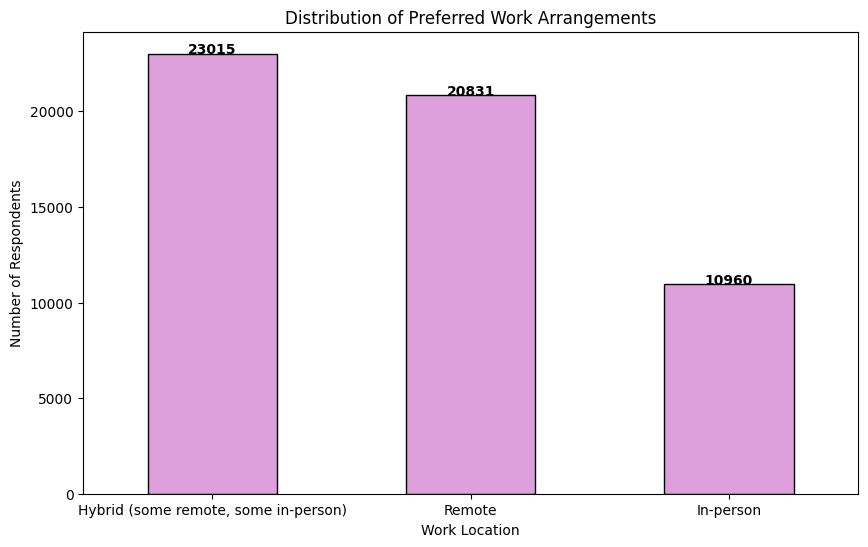

In [14]:
## Write your code here
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# 1. Connect to the correct database file
conn = sqlite3.connect('survey-data.sqlite')

# 2. Query the WorkLoc column from the 'main' table
query = "SELECT RemoteWork FROM main"
df_work = pd.read_sql_query(query, conn)
conn.close()

# 3. Clean and count the distribution
# This counts how many times each location appears
work_counts = df_work['RemoteWork'].value_counts()

# 4. Plot the "Categorical Histogram" (Bar Chart)
plt.figure(figsize=(10, 6))
work_counts.plot(kind='bar', color='plum', edgecolor='black')

# 5. Professional Lab Formatting
plt.title('Distribution of Preferred Work Arrangements')
plt.xlabel('Work Location')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=0) # Keep labels horizontal since they are short (Home/Office/Other)

# Adding exact counts on top of bars
for i, count in enumerate(work_counts):
    plt.text(i, count + 10, str(count), ha='center', fontweight='bold')

plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


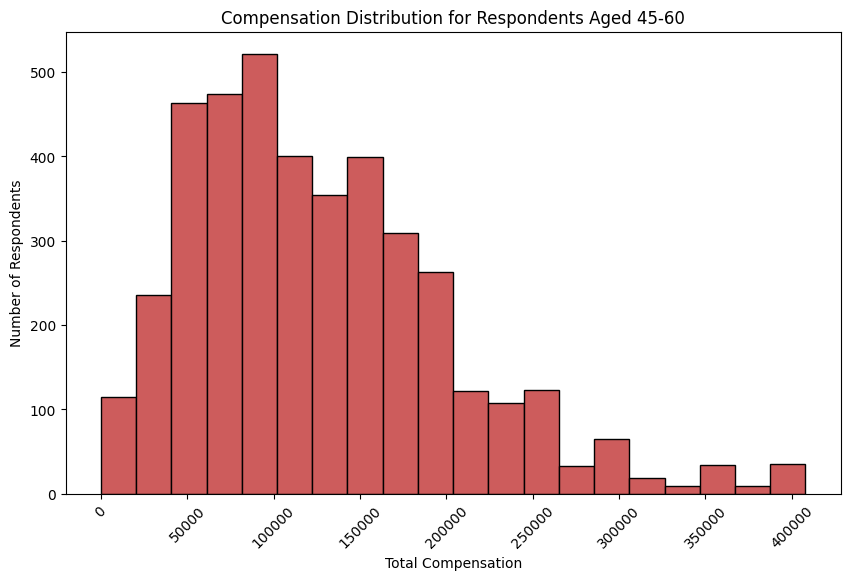

In [17]:
## Write your code here
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# 1. Connect and Query (Filtering directly in SQL is faster)
conn = sqlite3.connect('survey-data.sqlite')

# We grab all CompTotal entries where the Age is between 45 and 60
query = "SELECT CompTotal FROM main WHERE Age BETWEEN 45 AND 60"
df_mid_career = pd.read_sql_query(query, conn)
conn.close()

# 2. Filter Outliers (Essential so the bars aren't squashed)
Q1 = df_mid_career['CompTotal'].quantile(0.25)
Q3 = df_mid_career['CompTotal'].quantile(0.75)
IQR = Q3 - Q1
df_filtered = df_mid_career[(df_mid_career['CompTotal'] >= (Q1 - 1.5 * IQR)) & 
                            (df_mid_career['CompTotal'] <= (Q3 + 1.5 * IQR))]

# 3. Plot the Histogram
plt.figure(figsize=(10, 6))
plt.hist(df_filtered['CompTotal'].dropna(), bins=20, color='indianred', edgecolor='black')

plt.xticks(rotation=45)

# 4. Lab Formatting
plt.title('Compensation Distribution for Respondents Aged 45-60')
plt.xlabel('Total Compensation')
plt.ylabel('Number of Respondents')

plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


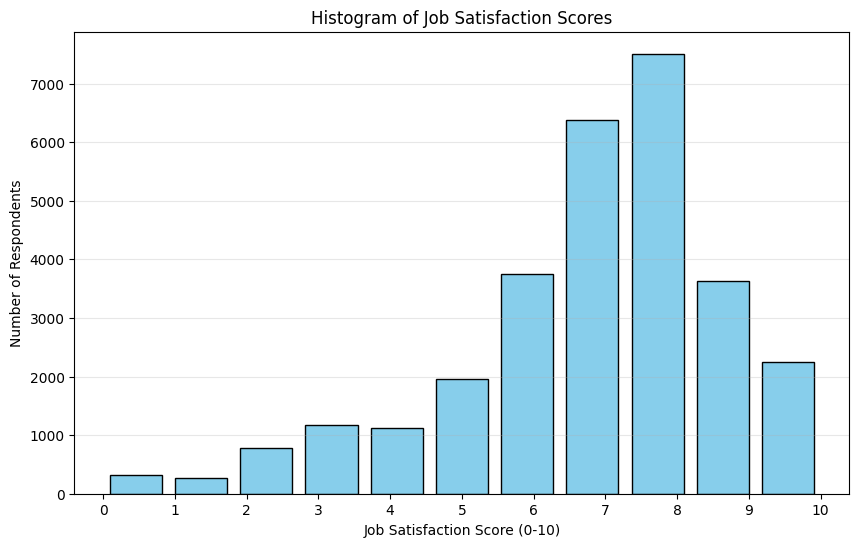

In [27]:
## Write your code here
 Drop rows where JobSat is missing (NaN)
df_clean = df.dropna(subset=['JobSat'])

# 4. Plot the Histogram
plt.figure(figsize=(10, 6))

# We use 11 bins because the scores go from 0 to 10
plt.hist(df_clean['JobSat'], bins=11, range=(0, 10), color='skyblue', edgecolor='black', rwidth=0.8)

# Adding titles and labels
plt.title('Histogram of Job Satisfaction Scores')
plt.xlabel('Job Satisfaction Score (0-10)')
plt.ylabel('Number of Respondents')

# Set the x-axis to show every number from 0 to 10
plt.xticks(range(11))

plt.grid(axis='y', alpha=0.3)
plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [28]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
